In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('../data/hypertension_engineered.csv')

# Drop all remaining raw text columns along with the target
columns_to_drop = [
    'Gender', 'Medication', 'Risk_Tier',
    'BP_History', 'Family_History', 'Exercise_Level', 
    'Smoking_Status', 'Has_Hypertension'
]
X = df.drop(columns=columns_to_drop)
y = df['Risk_Tier']

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print verification shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1588, 9)
X_test shape: (397, 9)


In [4]:
# Check the names of all columns left in your features
print(X.columns.tolist())

# Check the data type of each column to find the text one
print(X.dtypes)

['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration', 'BMI', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension', 'Systolic_BP', 'Diastolic_BP', 'Gender_Encoded', 'Medication_Encoded']
Age                     int64
Salt_Intake           float64
Stress_Score            int64
BP_History                str
Sleep_Duration        float64
BMI                   float64
Family_History            str
Exercise_Level            str
Smoking_Status            str
Has_Hypertension          str
Systolic_BP             int64
Diastolic_BP            int64
Gender_Encoded          int64
Medication_Encoded      int64
dtype: object


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_preds = dt_model.predict(X_test)

# Evaluate performance
print(f"Baseline Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, dt_preds))

Baseline Decision Tree Accuracy: 0.8564

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       157
           1       0.72      0.73      0.73       101
           2       0.93      0.83      0.88       139

    accuracy                           0.86       397
   macro avg       0.84      0.84      0.84       397
weighted avg       0.86      0.86      0.86       397



In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_preds = rf_model.predict(X_test)

# Evaluate performance
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9471

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       157
           1       0.92      0.87      0.89       101
           2       0.98      0.99      0.98       139

    accuracy                           0.95       397
   macro avg       0.94      0.94      0.94       397
weighted avg       0.95      0.95      0.95       397



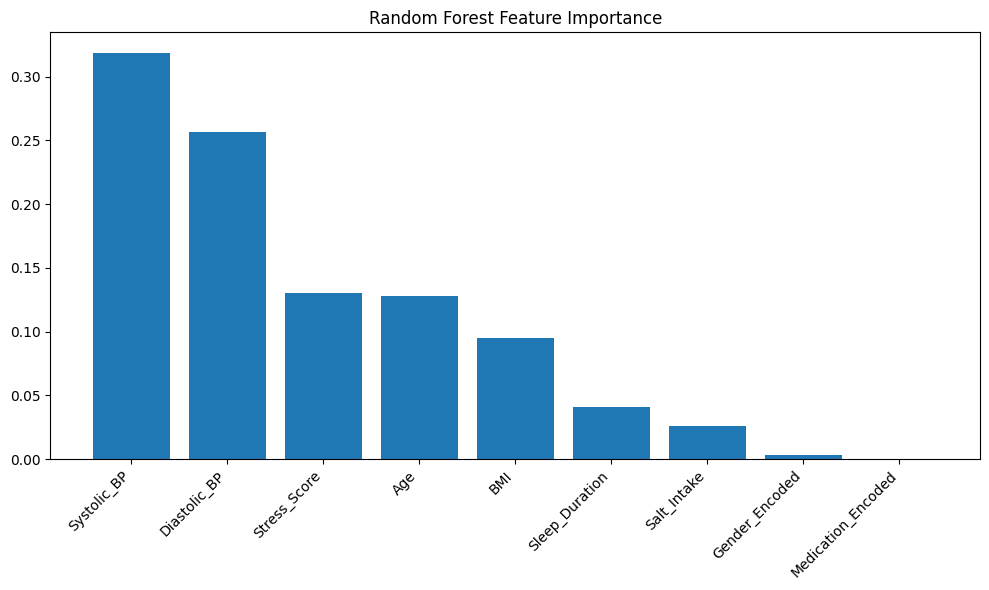

In [9]:
import matplotlib.pyplot as plt

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort importances in descending order (using -1 to reverse)
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

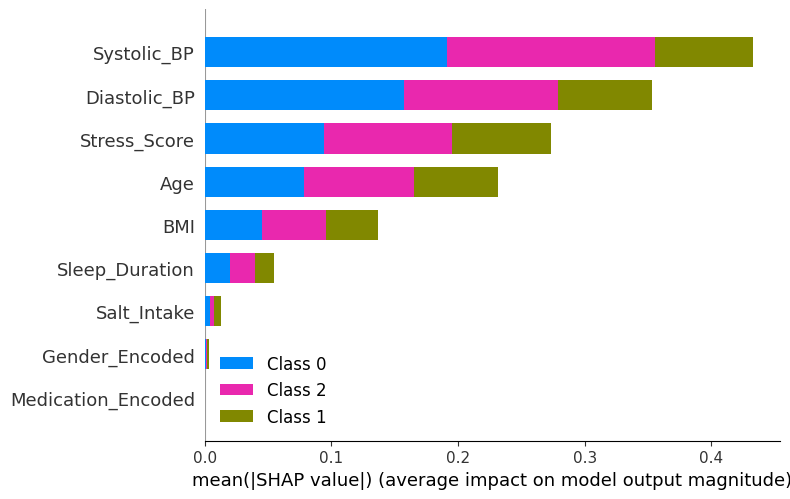

In [10]:
import shap

# Initialize the SHAP explainer with our random forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the summary (this will show the distribution per class)
shap.summary_plot(shap_values, X_test, plot_type="bar")

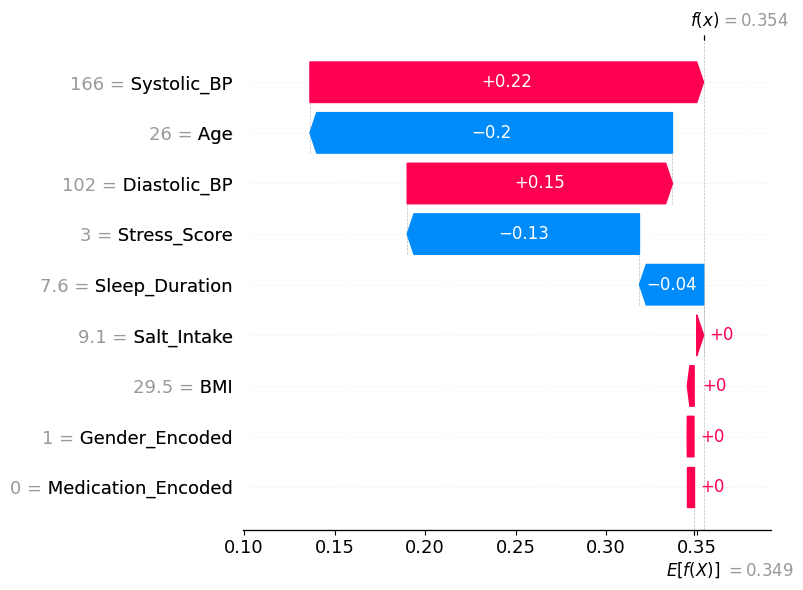

In [13]:
import shap
import matplotlib.pyplot as plt

patient_index = 0
class_index = 2

# Create an Explanation object for the specific class
# This perfectly aligns the shapes natively
explanation = shap.Explanation(
    values=shap_values[patient_index, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test.iloc[patient_index],
    feature_names=X_test.columns.tolist()
)

# Plot the waterfall chart
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()

In [14]:
import joblib

# Save the trained model to the models folder
joblib.dump(rf_model, '../models/hypertension_rf_model.pkl')
print("Model saved successfully as hypertension_rf_model.pkl")

Model saved successfully as hypertension_rf_model.pkl


In [15]:
import pandas as pd
import numpy as np

# Load your engineered dataset
df = pd.read_csv('../data/hypertension_engineered.csv')

# Calculate a compounding risk score based on vital and lifestyle metrics
raw_risk_score = (
    (df['Systolic_BP'] * 0.4) + 
    (df['Diastolic_BP'] * 0.3) + 
    (df['Stress_Score'] * 15) + 
    (df['BMI'] * 2)
)

# Normalize the score cleanly between 0.0 (Perfect Health) and 1.0 (Extreme Impending Crisis)
df['Future_Risk_Score'] = (raw_risk_score - raw_risk_score.min()) / (raw_risk_score.max() - raw_risk_score.min())

# Check the new target column we just created
print("Columns in dataset now:")
print(list(df.columns))
print("\nFirst few rows of our new Future Risk Target:")
print(df['Future_Risk_Score'].head())

Columns in dataset now:
['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration', 'BMI', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension', 'Systolic_BP', 'Diastolic_BP', 'Gender', 'Gender_Encoded', 'Medication_Encoded', 'Risk_Tier', 'Future_Risk_Score']

First few rows of our new Future Risk Target:
0    0.799453
1    0.765725
2    0.222881
3    0.874658
4    0.063355
Name: Future_Risk_Score, dtype: float64


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

# 1. Define the 9 clean numerical features we want to use
features = [
    'Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 
    'BMI', 'Systolic_BP', 'Diastolic_BP', 'Gender_Encoded', 'Medication_Encoded'
]

X_reg = df[features]
y_reg = df['Future_Risk_Score']

# 2. Split the data into 80% training and 20% testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Initialize and train the Random Forest Regressor
reg_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

# 4. Save the predictor model to your models folder
joblib.dump(reg_model, '../models/predictor.pkl')

print(" Forecasting Engine trained and saved successfully as 'predictor.pkl'!")
print(f"Predictor R² Score on Test Set: {reg_model.score(X_test_reg, y_test_reg):.4f}")

 Forecasting Engine trained and saved successfully as 'predictor.pkl'!
Predictor R² Score on Test Set: 0.9958


In [17]:
import numpy as np
import pandas as pd

def engineer_timeseries_features(patient_series):
    """
    Simulates a 14-day historical vital log for a patient 
    and extracts their baseline and trend slope.
    """
    current_sbp = patient_series['Systolic_BP']
    
    # Set a random seed based on the patient's age to keep results consistent
    np.random.seed(int(patient_series['Age']))
    
    # Simulate 14 days of prior blood pressure readings leading up to today
    history_days = 14
    
    # Create a baseline history with slight daily fluctuations
    historical_readings = np.random.normal(loc=current_sbp - 5, scale=4, size=history_days)
    
    # Calculate the patient's personal baseline (mean of their historical data)
    historical_baseline = np.mean(historical_readings)
    
    # Calculate the trend slope (difference between recent days and old days)
    recent_avg = np.mean(historical_readings[-3:])
    older_avg = np.mean(historical_readings[:3])
    trend_slope = recent_avg - older_avg
    
    return historical_baseline, trend_slope

# Test the feature extractor on the first patient
sample_patient = X_test.iloc[0]
baseline, trend = engineer_timeseries_features(sample_patient)

print("TIME-SERIES FEATURE EXTRACTION TEST:")
print(f"Current SBP: {sample_patient['Systolic_BP']} mmHg")
print(f"Calculated Historical Baseline: {baseline:.1f} mmHg")
print(f"Calculated 14-Day Trend Slope: {trend:+.1f} mmHg/week")

TIME-SERIES FEATURE EXTRACTION TEST:
Current SBP: 166.0 mmHg
Calculated Historical Baseline: 160.1 mmHg
Calculated 14-Day Trend Slope: -0.2 mmHg/week


In [18]:
import pandas as pd
import numpy as np

def master_decision_engine(patient_data, classifier, predictor, feature_names):
    # 1. Run Time-Series Feature Engineering
    historical_baseline, trend_slope = engineer_timeseries_features(patient_data)
    
    patient_df = pd.DataFrame([patient_data], columns=feature_names)
    sbp = patient_df['Systolic_BP'].values[0]
    stress = patient_df['Stress_Score'].values[0]
    
    # Calculate personalized deviation from historical baseline
    bp_deviation = sbp - historical_baseline
    
    # Establish personalized threshold based on historical trend stability
    personalized_threshold = 15.0 - (trend_slope * 2.0)
    
    # 2. Intelligent Switching Logic Gate
    is_volatile = (bp_deviation > personalized_threshold) or (stress >= 8) or (trend_slope > 5.0)
    
    print("=========================================")
    print("       BP CARE AI: DECISION ENGINE       ")
    print("=========================================")
    print("PATIENT LONGITUDINAL PERSONALIZATION:")
    print(f" - Current Systolic BP: {sbp} mmHg")
    print(f" - Historical Baseline SBP: {historical_baseline:.1f} mmHg")
    print(f" - Current Deviation From Baseline: {bp_deviation:+.1f} mmHg")
    print(f" - Personalized Threshold Limit: {personalized_threshold:.1f} mmHg")
    print(f" - 14-Day Trajectory Trend Slope: {trend_slope:+.1f} mmHg/week")
    print("-----------------------------------------")
    
    if is_volatile:
        # Route to Forecasting Model
        predicted_score = predictor.predict(patient_df)[0]
        print("ENGINE ROUTE: [ FORECASTING REGRESSION ]")
        print("REASON: Patient exceeded personalized historical deviation parameters.")
        print("-----------------------------------------")
        print(f"Predicted 7-Day Risk Score: {predicted_score:.4f} (Scale: 0.0 to 1.0)")
    else:
        # Route to Classification Model
        risk_labels = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk"}
        pred_class = int(classifier.predict(patient_df)[0])
        pred_proba = classifier.predict_proba(patient_df)[0][pred_class]
        
        print("ENGINE ROUTE: [ STANDARD CLASSIFICATION ]")
        print("REASON: Patient deviation is within safe historical baseline variances.")
        print("-----------------------------------------")
        print(f"Assigned Status: Class {pred_class} ({risk_labels[pred_class]})")
        print(f"Model Confidence: {pred_proba * 100:.2f}%")
        
    print("=========================================")

# Run the test case immediately on your sample patient
print("--- TEST CASE OUTCOME ---")
master_decision_engine(sample_patient, rf_model, reg_model, X.columns)

--- TEST CASE OUTCOME ---
       BP CARE AI: DECISION ENGINE       
PATIENT LONGITUDINAL PERSONALIZATION:
 - Current Systolic BP: 166.0 mmHg
 - Historical Baseline SBP: 160.1 mmHg
 - Current Deviation From Baseline: +5.9 mmHg
 - Personalized Threshold Limit: 15.3 mmHg
 - 14-Day Trajectory Trend Slope: -0.2 mmHg/week
-----------------------------------------
ENGINE ROUTE: [ STANDARD CLASSIFICATION ]
REASON: Patient deviation is within safe historical baseline variances.
-----------------------------------------
Assigned Status: Class 1 (Moderate Risk)
Model Confidence: 63.32%


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Generate predictions on the test dataset
y_pred_reg = reg_model.predict(X_test_reg)

# 2. Calculate the evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("=========================================")
print("     FORECASTING ENGINE PERFORMANCE      ")
print("=========================================")
print(f"R² Score (Variance Explained): {reg_model.score(X_test_reg, y_test_reg) * 100:.2f}%")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("=========================================")

     FORECASTING ENGINE PERFORMANCE      
R² Score (Variance Explained): 99.58%
Mean Absolute Error (MAE):     0.0114
Root Mean Squared Error (RMSE): 0.0150


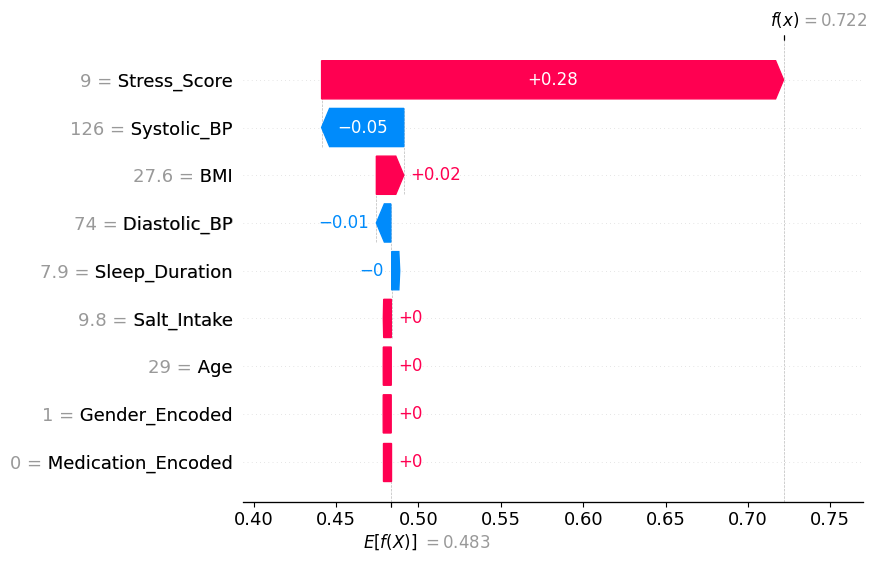

In [20]:
import shap

# 1. Initialize the Tree SHAP explainer saved regression model
explainer_reg = shap.TreeExplainer(reg_model)

# 2. Calculate SHAP values for the test set
shap_values_reg = explainer_reg(X_test_reg)

# 3. Plot the explanation for the first patient (index 0)

shap.plots.waterfall(shap_values_reg[0])

In [23]:
import joblib


classifier = joblib.load('../models/hypertension_rf_model.pkl')
predictor = joblib.load('../models/predictor.pkl')

print("Models loaded successfully from the parent directory paths!")

Models loaded successfully from the parent directory paths!


In [24]:
# Create a dictionary of different patient scenarios
test_scenarios = {
    "Patient_1_Stable_Chronic": {
        "current_data": {
            "Age": 55, "Gender": 1, "Systolic_BP": 162.0, "Diastolic_BP": 95.0,
            "BMI": 28.5, "Heart_Rate": 74, "Stress_Score": 4, "Sleep_Duration": 7.0, "Physical_Activity": 3
        },
        # History matches current reading closely (Stable high baseline)
        "history": [160.0, 161.0, 159.5, 160.5, 161.2, 160.8, 162.0] 
    },
    
    "Patient_2_Acute_Spike": {
        "current_data": {
            "Age": 42, "Gender": 0, "Systolic_BP": 165.0, "Diastolic_BP": 98.0,
            "BMI": 24.2, "Heart_Rate": 88, "Stress_Score": 6, "Sleep_Duration": 5.5, "Physical_Activity": 2
        },
        # Normal baseline is low, meaning this 165 is a sudden dangerous spike
        "history": [132.0, 134.0, 131.5, 135.0, 138.0, 140.0, 142.0] 
    },
    
    "Patient_3_Extreme_Stress": {
        "current_data": {
            "Age": 38, "Gender": 1, "Systolic_BP": 138.0, "Diastolic_BP": 85.0,
            "BMI": 26.0, "Heart_Rate": 92, "Stress_Score": 9, "Sleep_Duration": 4.0, "Physical_Activity": 1
        },
        # BP is slightly elevated but stable; however, Stress Score is a 9/10
        "history": [135.0, 136.0, 135.5, 137.0, 136.8, 137.2, 138.0] 
    }
}

print("Test patient scenarios initialized successfully!")

Test patient scenarios initialized successfully!


In [26]:
def run_live_simulation(scenario_name, data_dict):
    current_vitals = data_dict["current_data"]
    history_logs = data_dict["history"]
    
    # 1. Simulate Time-Series Baseline & Trend
    historical_baseline = np.mean(history_logs)
    x = np.arange(len(history_logs))
    trend_slope = np.polyfit(x, history_logs, 1)[0] * 7  
    
    sbp = current_vitals.get('Systolic_BP', 130.0)
    stress = current_vitals.get('Stress_Score', 4)
    bp_deviation = sbp - historical_baseline
    personalized_threshold = 15.0 - (trend_slope * 2.0)
    
    is_volatile = (bp_deviation > personalized_threshold) or (stress >= 8) or (trend_slope > 5.0)
    
    # 2. Get the exact columns the model expects
    expected_features = classifier.feature_names_in_
    
    # 3. Dynamically map our test vitals to what the model wants
    # If a model expects an encoded or missing column, we provide a smart default fallback
    mapping_dict = {
        'Age': current_vitals.get('Age', 45),
        'Systolic_BP': sbp,
        'Diastolic_BP': current_vitals.get('Diastolic_BP', 80.0),
        'BMI': current_vitals.get('BMI', 25.0),
        'Stress_Score': stress,
        'Sleep_Duration': current_vitals.get('Sleep_Duration', 7.0),
        'Gender_Encoded': current_vitals.get('Gender', 1),
        'Medication_Encoded': 0,  # Default fallback value
        'Salt_Intake': 1          # Default fallback value
    }
    
    # Construct a single row containing only the features expected by the model
    ordered_row = {feat: mapping_dict.get(feat, 0) for feat in expected_features}
    patient_df = pd.DataFrame([ordered_row], columns=expected_features)
    
    print("\n" + "="*50)
    print(f" LIVE TEST RUN FOR: {scenario_name.upper()} ")
    print("="*50)
    print(f"Current Systolic BP:        {sbp} mmHg")
    print(f"Historical Baseline SBP:   {historical_baseline:.1f} mmHg")
    print(f"Current Deviation:         {bp_deviation:+.1f} mmHg")
    print(f"Personalized Threshold:     {personalized_threshold:.1f} mmHg")
    print(f"14-Day Trend Slope:        {trend_slope:+.1f} mmHg/week")
    print(f"Patient Stress Score:       {stress}/10")
    print("-"*50)
    
    if is_volatile:
        # Route to Forecasting Model (Predictor)
        predicted_score = predictor.predict(patient_df)[0]
        print("ENGINE ROUTE: [ FORECASTING REGRESSION ]")
        print("REASON: Critical spike deviation or psychological trigger breached.")
        print(f"Predicted 7-Day Risk Score: {predicted_score:.4f} (Scale: 0.0 to 1.0)")
    else:
        # Route to Classification Model (Classifier)
        risk_labels = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk"}
        pred_class = int(classifier.predict(patient_df)[0])
        pred_proba = classifier.predict_proba(patient_df)[0][pred_class]
        
        print("ENGINE ROUTE: [ STANDARD CLASSIFICATION ]")
        print("REASON: Patient metrics are bounded within baseline variances.")
        print(f"Assigned Status: Class {pred_class} ({risk_labels[pred_class]})")
        print(f"Model Confidence: {pred_proba * 100:.2f}%")
    print("="*50)

# Run the 3 patients through the aligned architecture
for name, data in test_scenarios.items():
    run_live_simulation(name, data)


 LIVE TEST RUN FOR: PATIENT_1_STABLE_CHRONIC 
Current Systolic BP:        162.0 mmHg
Historical Baseline SBP:   160.7 mmHg
Current Deviation:         +1.3 mmHg
Personalized Threshold:     11.4 mmHg
14-Day Trend Slope:        +1.8 mmHg/week
Patient Stress Score:       4/10
--------------------------------------------------
ENGINE ROUTE: [ STANDARD CLASSIFICATION ]
REASON: Patient metrics are bounded within baseline variances.
Assigned Status: Class 2 (High Risk)
Model Confidence: 62.33%

 LIVE TEST RUN FOR: PATIENT_2_ACUTE_SPIKE 
Current Systolic BP:        165.0 mmHg
Historical Baseline SBP:   136.1 mmHg
Current Deviation:         +28.9 mmHg
Personalized Threshold:     -9.2 mmHg
14-Day Trend Slope:        +12.1 mmHg/week
Patient Stress Score:       6/10
--------------------------------------------------
ENGINE ROUTE: [ FORECASTING REGRESSION ]
REASON: Critical spike deviation or psychological trigger breached.
Predicted 7-Day Risk Score: 0.5900 (Scale: 0.0 to 1.0)

 LIVE TEST RUN FOR: